# Training PPE Compliance

Training YOLO26m untuk deteksi 14 kelas PPE.

**Dataset:** `research/datasets/raw/ppe/` — 30.756 train, 8.810 valid, 4.423 test.

**Catatan dari profil data (`01_data.ipynb`):**
- Hardhat dominan (38.7%), Person paling sedikit (1.3%)
- Rasio max/min ~29x — tapi semua kelas > 1.000 instance, cukup aman
- Bbox cenderung kecil tapi masih wajar untuk imgsz=640

**Output:** `best.pt` di `research/runs/detect/ppe_compliance_yolo26m/weights/`.

## Alur

1. Setup
2. Training (set `RUN_TRAINING = True`)
3. Load run terakhir
4. Evaluasi (metrik agregat + per-class)
5. Visualisasi (training curves, confusion matrix, sample prediksi)

## Setup

In [1]:
%matplotlib inline

from __future__ import annotations

import contextlib
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import yaml
from PIL import Image
from ultralytics import YOLO

NOTEBOOK_DIR = Path.cwd()
RESEARCH_DIR = NOTEBOOK_DIR.parents[1]
AI_DIR       = NOTEBOOK_DIR.parents[2]

DATASET_DIR  = RESEARCH_DIR / "datasets" / "raw" / "ppe"
DATA_YAML    = DATASET_DIR / "data.yaml"
BASE_MODEL   = AI_DIR / "models" / "yolo26m.pt"

RUNS_DIR      = RESEARCH_DIR / "runs" / "detect"
ARTIFACTS_DIR = RESEARCH_DIR / "artifacts" / "ppe_compliance"
ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_NAME = "ppe_compliance_yolo26m"
SEED     = 42

for p in [DATA_YAML, BASE_MODEL]:
    if not p.exists():
        raise FileNotFoundError(f"Nggak ketemu: {p}")

cfg = yaml.safe_load(DATA_YAML.read_text(encoding="utf-8"))
print("Dataset:", DATASET_DIR)
print("Base model:", BASE_MODEL)
print("Kelas:", cfg["names"])

Dataset: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\raw\ppe
Base model: c:\Users\istd.magang125\Documents\cctv-insight\ai\models\yolo26m.pt
Kelas: ['Fall-Detected', 'Gloves', 'Goggles', 'Hardhat', 'Ladder', 'Mask', 'NO-Gloves', 'NO-Goggles', 'NO-Hardhat', 'NO-Mask', 'NO-Safety Vest', 'Person', 'Safety Cone', 'Safety Vest']


## Training

Set `RUN_TRAINING = True` untuk mulai training. Default `False` supaya nggak ke-trigger kalau re-run notebook.

Estimasi waktu di RTX 4060 Laptop:
- imgsz=640, 50 epoch: ~3-5 jam
- imgsz=640, 100 epoch: ~6-10 jam

Patience=20 → otomatis berhenti kalau val loss nggak turun selama 20 epoch.

In [2]:
RUN_TRAINING = True

TRAIN_CFG = {
    "epochs": 6,
    "imgsz": 640,
    "batch": 8,
    "workers": 4,
    "patience": 3,
    "seed": SEED,
    "project": str(RUNS_DIR),
    "name": RUN_NAME,
}


@contextlib.contextmanager
def _cwd(path):
    prev = os.getcwd()
    os.chdir(str(path))
    try:
        yield
    finally:
        os.chdir(prev)


if RUN_TRAINING:
    with _cwd(AI_DIR / "models"):
        model = YOLO(str(BASE_MODEL))
        result = model.train(data=str(DATA_YAML), **TRAIN_CFG)
    print("Training kelar:", result.save_dir)
else:
    print("Training di-skip. Set RUN_TRAINING=True kalau mau training.")

New https://pypi.org/project/ultralytics/8.4.46 available  Update with 'pip install -U ultralytics'
Ultralytics 8.4.38  Python-3.14.3 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=c:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\raw\ppe\data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=6, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=

## Load Run Terakhir

Cari folder run paling baru dengan prefix `ppe_compliance_yolo26m`, ambil `best.pt` untuk evaluasi.

In [3]:
def find_latest_run(prefix: str) -> Path:
    candidates = [
        d for d in RUNS_DIR.glob(f"{prefix}*")
        if d.is_dir() and (d / "weights" / "best.pt").exists()
    ]
    if not candidates:
        raise FileNotFoundError(f"Belum ada run dengan prefix '{prefix}' di {RUNS_DIR}")
    return max(candidates, key=lambda d: d.stat().st_mtime)


run_dir     = find_latest_run(RUN_NAME)
best_pt     = run_dir / "weights" / "best.pt"
results_csv = run_dir / "results.csv"
eval_model  = YOLO(str(best_pt))

print("Run dir:", run_dir)
print("Best weights:", best_pt)
print("Kelas:", eval_model.names)

Run dir: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\runs\detect\ppe_compliance_yolo26m4
Best weights: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\runs\detect\ppe_compliance_yolo26m4\weights\best.pt
Kelas: {0: 'Fall-Detected', 1: 'Gloves', 2: 'Goggles', 3: 'Hardhat', 4: 'Ladder', 5: 'Mask', 6: 'NO-Gloves', 7: 'NO-Goggles', 8: 'NO-Hardhat', 9: 'NO-Mask', 10: 'NO-Safety Vest', 11: 'Person', 12: 'Safety Cone', 13: 'Safety Vest'}


## Evaluasi

Metrik agregat di split valid: mAP50, mAP50-95, Precision, Recall.

In [4]:
val = eval_model.val(data=str(DATA_YAML), imgsz=640, conf=0.25, verbose=False)

metrics = {
    "mAP50":     round(float(val.box.map50), 3),
    "mAP50-95":  round(float(val.box.map),   3),
    "Precision": round(float(val.box.mp),    3),
    "Recall":    round(float(val.box.mr),    3),
}
print("Metrik agregat:")
print(pd.DataFrame([metrics]).to_string(index=False))

Ultralytics 8.4.38  Python-3.14.3 torch-2.11.0+cu126 CUDA:0 (NVIDIA GeForce RTX 4060 Laptop GPU, 8188MiB)
YOLO26m summary (fused): 132 layers, 20,360,246 parameters, 0 gradients, 67.9 GFLOPs
val: Fast image access  (ping: 0.00.0 ms, read: 666.7276.3 MB/s, size: 53.4 KB)
val: Scanning C:\Users\istd.magang125\Documents\cctv-insight\ai\research\datasets\raw\ppe\valid\labels.cache... 8810 images, 210 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 8810/8810 3.1Git/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 551/551 1.8it/s 5:09<0.5s
                   all       8810      22059      0.714      0.769      0.678       0.43
Speed: 1.3ms preprocess, 31.5ms inference, 0.0ms loss, 0.1ms postprocess per image
Results saved to C:\Users\istd.magang125\Documents\backend\runs\detect\val24
Metrik agregat:
 mAP50  mAP50-95  Precision  Recall
 0.678      0.43      0.714   0.769


### Per-Class Metrics

Penting untuk cek kelas minoritas (Person, Ladder, NO-Safety Vest) — apakah model cukup belajar.

In [5]:
class_indices = val.box.ap_class_index.astype(int).tolist()
per_class = []
for i, ci in enumerate(class_indices):
    p, r, ap50, ap = val.box.class_result(i)
    per_class.append({
        "class":     val.names[ci],
        "Precision": round(float(p), 3),
        "Recall":    round(float(r), 3),
        "mAP50":     round(float(ap50), 3),
        "mAP50-95":  round(float(ap), 3),
    })
per_class_df = pd.DataFrame(per_class)
print("Per-class metrics:")
print(per_class_df.to_string(index=False))

per_class_csv = ARTIFACTS_DIR / "per_class_metrics.csv"
per_class_df.to_csv(per_class_csv, index=False)
print(f"\nTersimpan: {per_class_csv}")

Per-class metrics:
         class  Precision  Recall  mAP50  mAP50-95
 Fall-Detected      0.696   0.795  0.714     0.461
        Gloves      0.802   0.923  0.866     0.446
       Goggles      0.760   0.959  0.917     0.543
       Hardhat      0.805   0.894  0.857     0.479
        Ladder      0.924   0.910  0.904     0.748
          Mask      0.485   0.780  0.413     0.298
     NO-Gloves      0.783   0.777  0.738     0.346
    NO-Goggles      0.789   0.885  0.838     0.469
    NO-Hardhat      0.607   0.823  0.679     0.439
       NO-Mask      0.555   0.705  0.482     0.312
NO-Safety Vest      0.495   0.134  0.079     0.041
        Person      0.912   0.902  0.895     0.732
   Safety Cone      0.760   0.675  0.623     0.347
   Safety Vest      0.625   0.603  0.493     0.358

Tersimpan: c:\Users\istd.magang125\Documents\cctv-insight\ai\research\artifacts\ppe_compliance\per_class_metrics.csv


## Visualisasi

### Training Curves

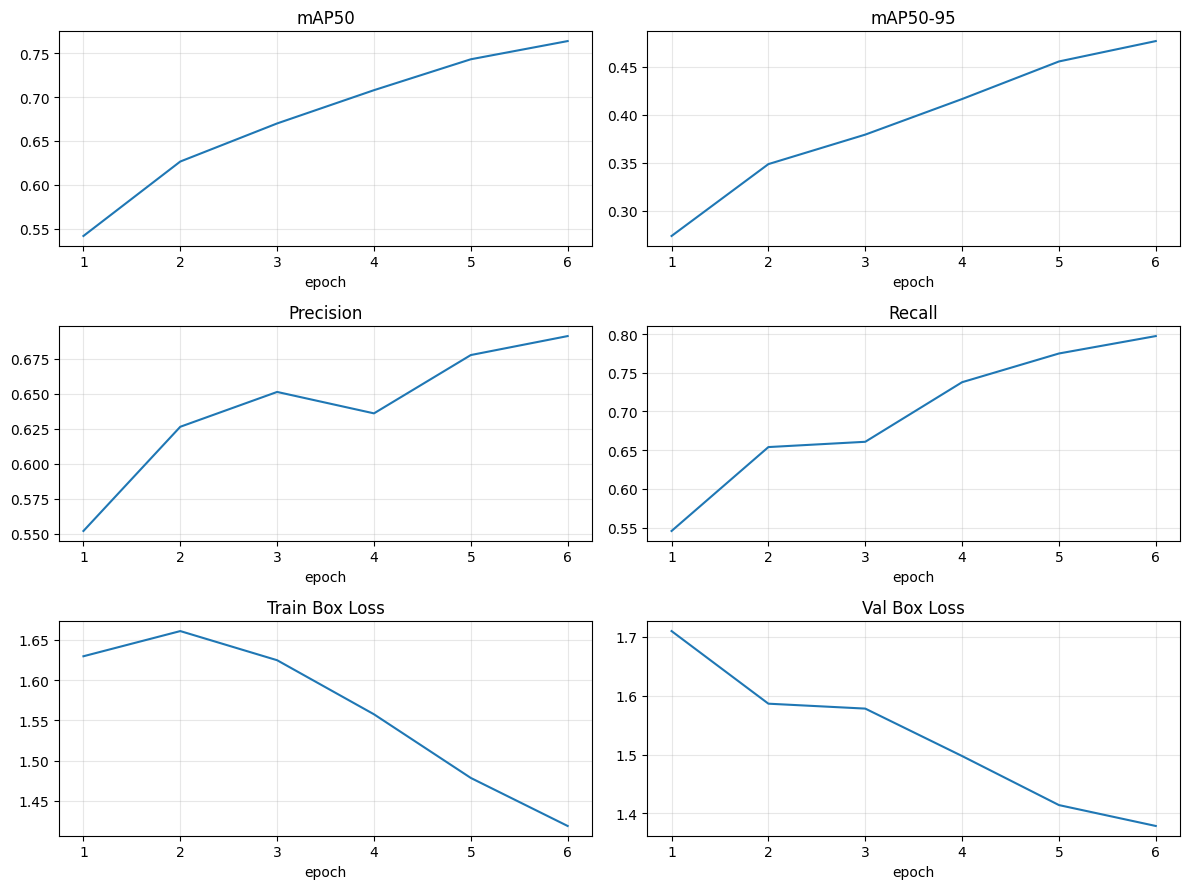

In [6]:
df = pd.read_csv(results_csv)
df.columns = [c.strip() for c in df.columns]

curves = [
    ("metrics/mAP50(B)",     "mAP50"),
    ("metrics/mAP50-95(B)",  "mAP50-95"),
    ("metrics/precision(B)", "Precision"),
    ("metrics/recall(B)",    "Recall"),
    ("train/box_loss",       "Train Box Loss"),
    ("val/box_loss",         "Val Box Loss"),
]
available = [(c, label) for c, label in curves if c in df.columns]
rows_n = (len(available) + 1) // 2
fig, axes = plt.subplots(rows_n, 2, figsize=(12, 3 * rows_n))
axes = axes.flatten()
for ax, (col, label) in zip(axes, available):
    ax.plot(df["epoch"], df[col])
    ax.set_title(label)
    ax.set_xlabel("epoch")
    ax.grid(alpha=0.3)
for ax in axes[len(available):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

### Per-Class Bar Chart + Confusion Matrix

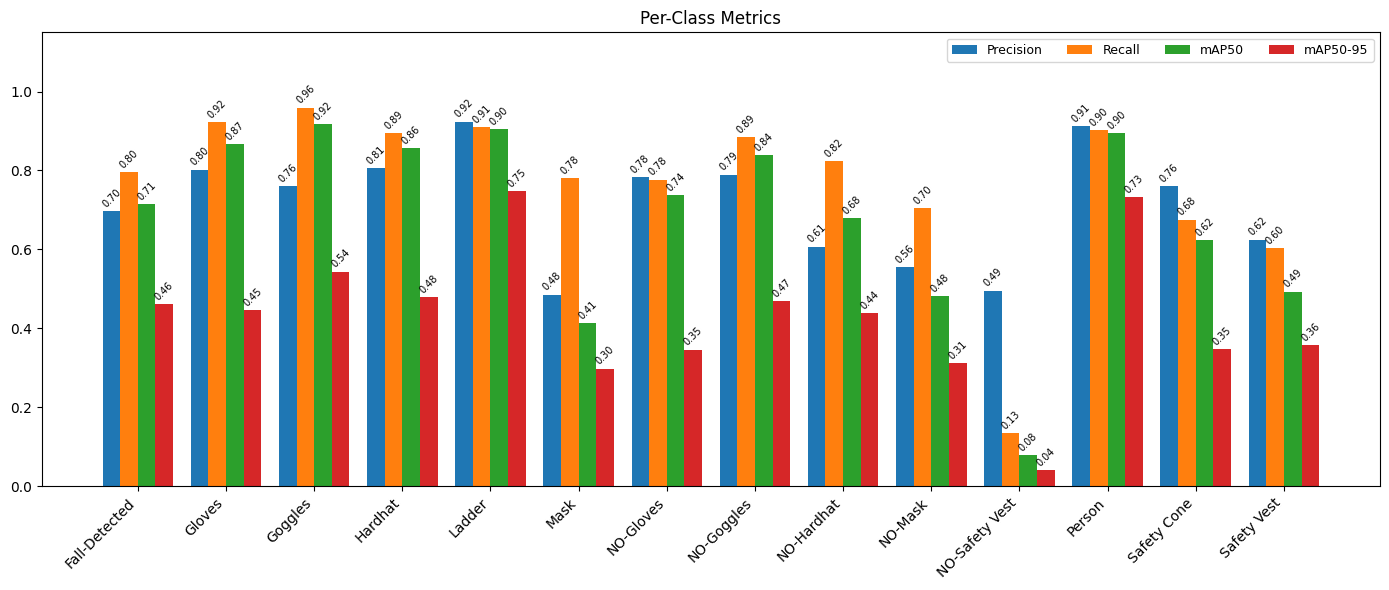

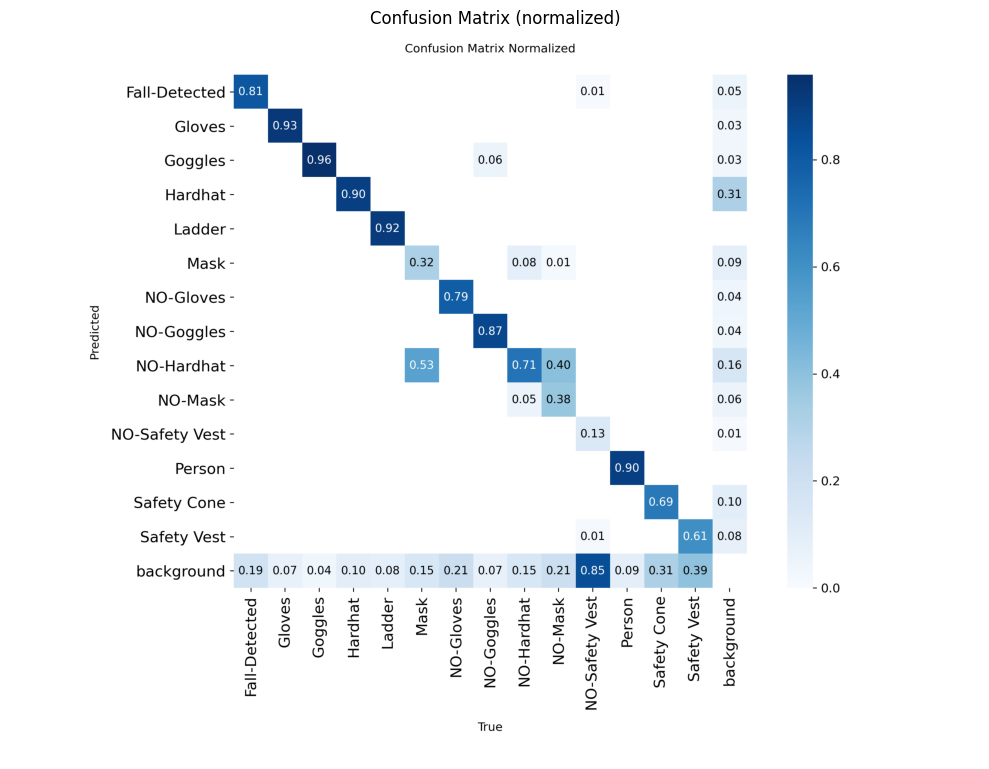

In [7]:
fig, ax = plt.subplots(figsize=(14, 6))
to_plot = ["Precision", "Recall", "mAP50", "mAP50-95"]
x = list(range(len(per_class_df)))
width = 0.2
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]
for j, m in enumerate(to_plot):
    offset = (j - 1.5) * width
    bars = ax.bar([xi + offset for xi in x], per_class_df[m], width, label=m, color=colors[j])
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.01,
                f"{b.get_height():.2f}", ha="center", fontsize=7, rotation=45)
ax.set_xticks(x)
ax.set_xticklabels(per_class_df["class"], rotation=45, ha="right")
ax.set_ylim(0, 1.15)
ax.set_title("Per-Class Metrics")
ax.legend(loc="upper right", ncol=4, fontsize=9)
plt.tight_layout()
plt.show()

cm_path = Path(val.save_dir) / "confusion_matrix_normalized.png"
if cm_path.exists():
    fig, ax = plt.subplots(figsize=(10, 9))
    ax.imshow(Image.open(cm_path))
    ax.set_title("Confusion Matrix (normalized)")
    ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("Confusion matrix nggak ketemu di:", cm_path)

### Sample Prediksi

Prediksi di gambar test untuk sanity check visual.

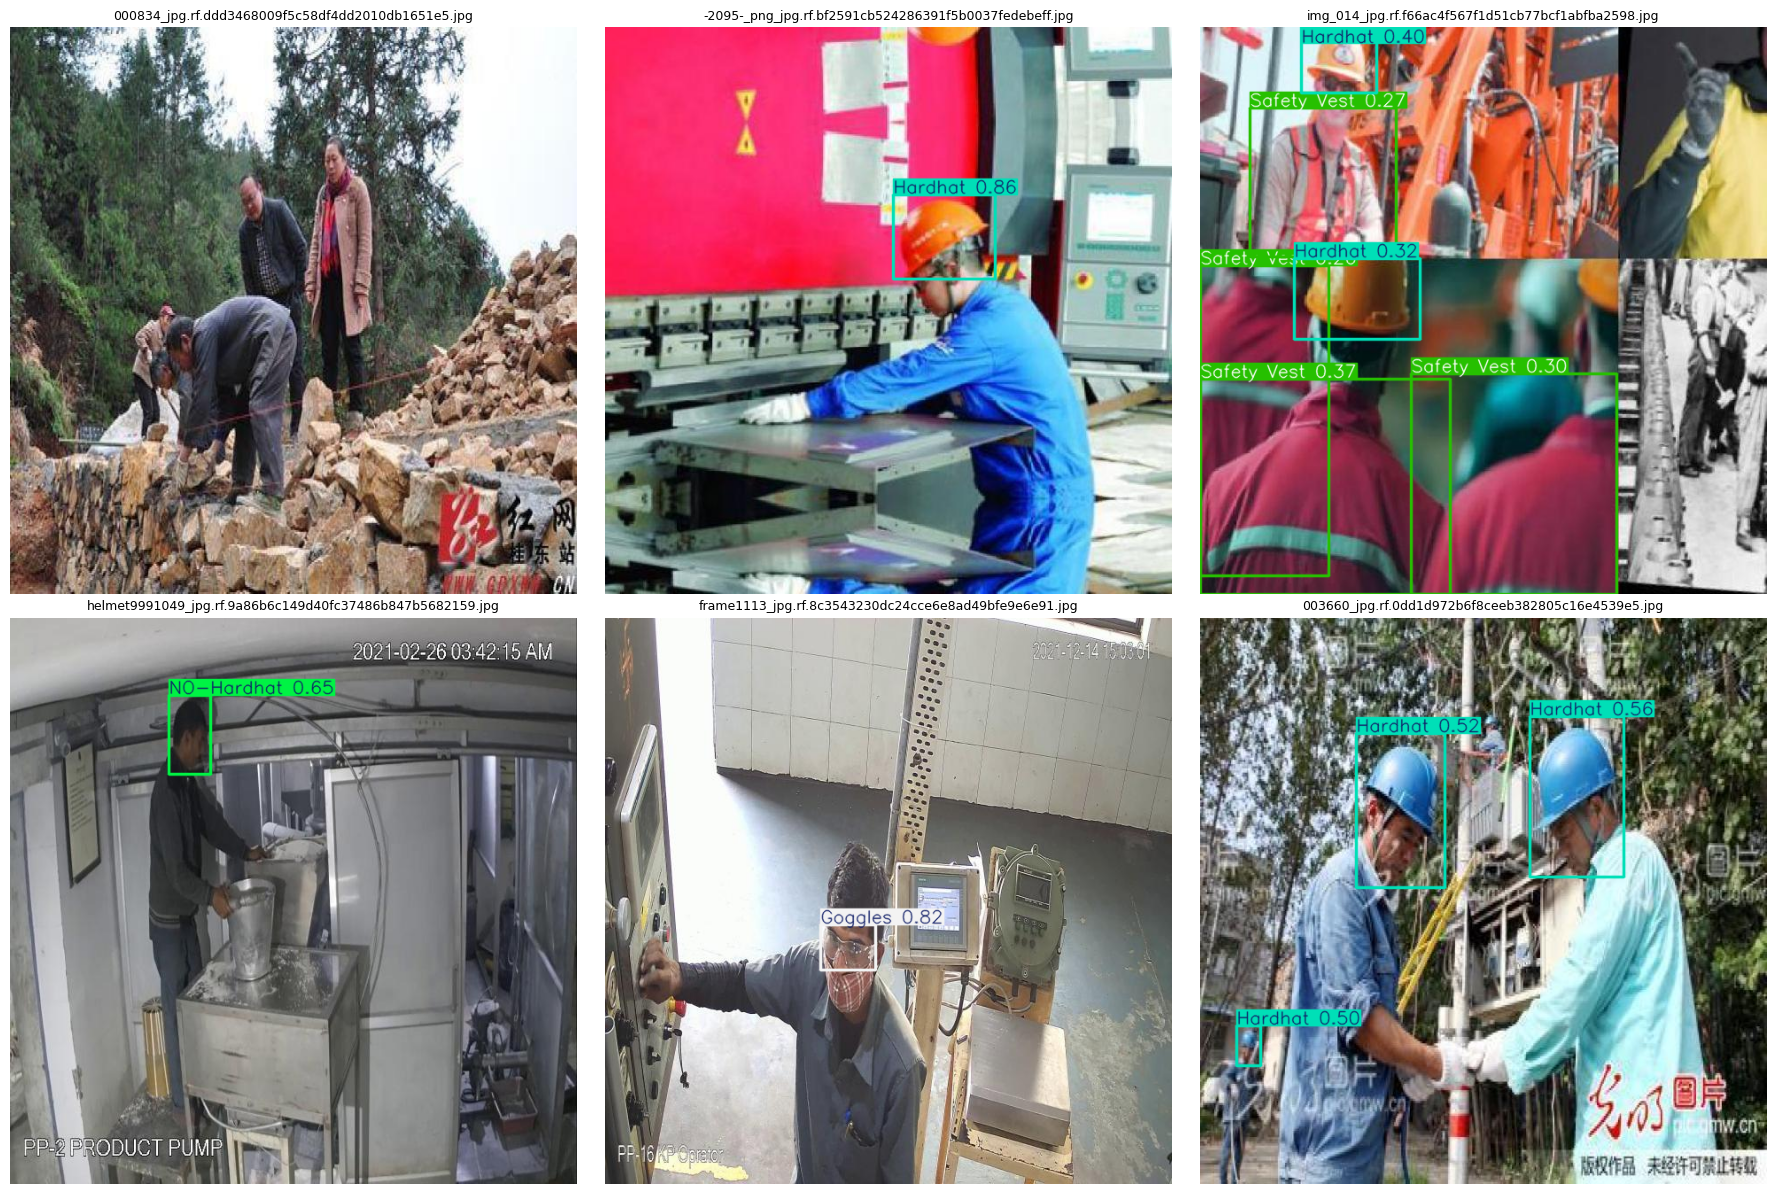

In [8]:
N_SAMPLES = 6
test_dir = DATASET_DIR / "test" / "images"
test_images: list[Path] = []
for ext in ("*.jpg", "*.jpeg", "*.png"):
    test_images.extend(sorted(test_dir.glob(ext)))

samples = random.Random(SEED).sample(test_images, min(N_SAMPLES, len(test_images)))

cols = 3
rows_n = (len(samples) + cols - 1) // cols
fig, axes = plt.subplots(rows_n, cols, figsize=(18, 6 * rows_n))
axes = axes.flatten()
for ax, img_path in zip(axes, samples):
    r = eval_model.predict(str(img_path), conf=0.25, imgsz=640, verbose=False)[0]
    ax.imshow(r.plot()[..., ::-1])
    ax.set_title(img_path.name, fontsize=9)
    ax.axis("off")
for ax in axes[len(samples):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## Kesimpulan

Isi setelah training dan evaluasi selesai.

**Patokan:**

| mAP50 | Verdict |
|---|---|
| >= 0.80 | Bagus, siap register ke service |
| 0.60 - 0.80 | Lumayan, cek per-class mana yang lemah |
| < 0.60 | Kurang, perlu tuning (epoch, imgsz, augmentasi) |

**Kalau hasilnya kurang:**
- Naikin `epochs` ke 100
- Naikin `imgsz` ke 1280 (terutama kalau objek kecil mAP-nya rendah)
- Cek confusion matrix — kelas mana yang sering ke-tukar

**Langkah berikutnya:**
- Register model di [registry.py](../../../src/cctv_insight_ai/models/registry.py) dengan `class_labels` mapping
- Update `CHECK_TO_MODEL` untuk routing check ke model baru
- Test via API (`POST /v1/infer`)